# Percobaan 1 : Resize dan Grayscale

## Import Library

In [4]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Cell code di atas merupakan code untuk mengimport seluruh library yang dibutuhkan dalam pengerjaan ekstraksi fitur citra serta proses klasifikasi pada jurnal ini. Library cv2 yang diimport sebagai "cv" digunakan untuk membaca dan mengolah citra, sedangkan numpy ("np") berfungsi untuk merepresentasikan citra dalam bentuk array piksel agar dapat diolah secara numerik. Library matplotlib.pyplot ("plt") dan seaborn (sns) dibutuhkan untuk menampilkan visualisasi, baik berupa citra hasil pengolahan maupun grafik seperti histogram dan confusion matrix, sementara pandas ("pd") digunakan untuk mengelola dan menganalisis data dalam bentuk tabel. Untuk proses ekstraksi fitur tekstur, digunakan fungsi graycomatrix dan graycoprops dari library skimage.feature yang berguna untuk menghitung matriks co-occurrence dan properti tekstur citra seperti kontras, homogenitas, dan korelasi, serta fungsi entropy dari scipy.stats untuk mengukur tingkat keacakan informasi pada citra.

Selanjutnya, library sklearn.model_selection diimport untuk mengambil fungsi train_test_split yang digunakan dalam membagi data menjadi data latih dan data uji, serta cross_val_predict yang digunakan untuk melakukan validasi silang terhadap model klasifikasi. Tiga algoritma klasifikasi yang digunakan dalam jurnal ini diimport dari masing-masing modulnya, yaitu RandomForestClassifier dari sklearn.ensemble, SVC (Support Vector Classifier) dari sklearn.svm, dan KNeighborsClassifier dari sklearn.neighbors, sehingga ketiga model ini nantinya dapat dibandingkan performanya dalam mengklasifikasikan citra.

Terakhir, untuk keperluan evaluasi performa model, diimport beberapa fungsi metrik dari sklearn.metrics seperti accuracy_score untuk mengukur akurasi, precision_score dan recall_score untuk mengukur ketepatan serta kemampuan model dalam mengenali kelas tertentu, f1_score sebagai nilai gabungan dari precision dan recall, serta classification_report yang menyajikan keseluruhan metrik tersebut secara ringkas dalam satu tabel. Selain itu, confusion_matrix dan ConfusionMatrixDisplay juga diimport untuk membuat dan menampilkan matriks kebingungan model secara visual, sehingga memudahkan dalam menganalisis kesalahan klasifikasi yang terjadi pada setiap kelas.

## Resize

In [7]:
def resize(image, target_size):

    original_height, original_width, _ = image.shape
    target_width, target_height = target_size
    resized = np.zeros((target_height, target_width, 3), dtype=np.uint8)
    
    for i in range(target_height):
        for j in range(target_width):
            original_x = int(j * original_width / target_width)
            original_y = int(i * original_height / target_height)
            resized[i, j] = image[original_y, original_x]
    
    return resized

Cell code di atas merupakan implementasi manual dari fungsi resize citra menggunakan metode nearest neighbor interpolation, tanpa memanfaatkan fungsi resize bawaan dari library cv2. Fungsi ini bekerja dengan cara membuat array kosong baru ("resized") berukuran sesuai target_size yang diinginkan, kemudian mengisi setiap piksel pada array tersebut melalui dua buah perulangan for yang menyusuri tinggi (i) dan lebar (j) citra target. Untuk setiap posisi piksel pada citra hasil, dilakukan perhitungan koordinat asal (original_x dan original_y) pada citra original dengan cara mengalikan posisi piksel target dengan rasio antara ukuran original dan ukuran target, sehingga nilai piksel dari citra asli pada koordinat tersebut dapat diambil dan dipetakan ke posisi yang bersesuaian pada citra hasil resize.

## Data Loading

In [13]:
data = []
labels = []
file_name = []
for sub_folder in os.listdir("Assets\\"):
    sub_folder_files = os.listdir(os.path.join("Assets\\", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets\\", sub_folder, filename)
        img = cv.imread(img_path)
        img = resize(img, (480, 640))
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
        data.append(img)
        labels.append(sub_folder)
        name = os.path.splitext(filename)[0]
        file_name.append(filename)
        
data = np.array(data)
labels = np.array(labels)
print("Data: ", len(data))
print("Label: ", len(labels))
print("Filenames: ", len(file_name))


Data:  200
Label:  200
Filenames:  200


Cell code di atas merupakan proses pembacaan dan pemuatan seluruh citra yang terdapat pada folder "Assets" untuk kemudian diolah lebih lanjut. Pertama, dilakukan perulangan terhadap setiap sub_folder yang ada di dalam folder Assets, di mana setiap sub_folder ini diasumsikan merepresentasikan satu label atau kelas tertentu. Selanjutnya, setiap file citra yang berada di dalam masing-masing sub_folder dibaca menggunakan cv.imread, kemudian diubah ukurannya menjadi 480x640 piksel menggunakan fungsi resize yang telah didefinisikan sebelumnya, dan diubah pula menjadi citra grayscale menggunakan cv.cvtColor agar proses ekstraksi fitur pada tahap berikutnya menjadi lebih sederhana karena hanya berfokus pada satu channel intensitas piksel saja.

Setiap citra yang telah diproses tersebut kemudian dimasukkan ke dalam list "data", sementara nama sub_folder-nya dimasukkan ke dalam list "labels" sebagai keterangan kelas dari citra yang bersangkutan, dan nama file aslinya disimpan ke dalam list "file_name" untuk keperluan penelusuran data di kemudian hari. Setelah seluruh citra berhasil dimuat, list "data" dan "labels" tersebut diubah menjadi array numpy agar dapat lebih mudah diolah pada proses-proses selanjutnya, dan terakhir ditampilkan jumlah data, label, serta filename yang berhasil dimuat sebagai bentuk verifikasi bahwa proses pembacaan data telah berjalan dengan baik dan sesuai dengan jumlah file yang ada.

### Menampilkan citra

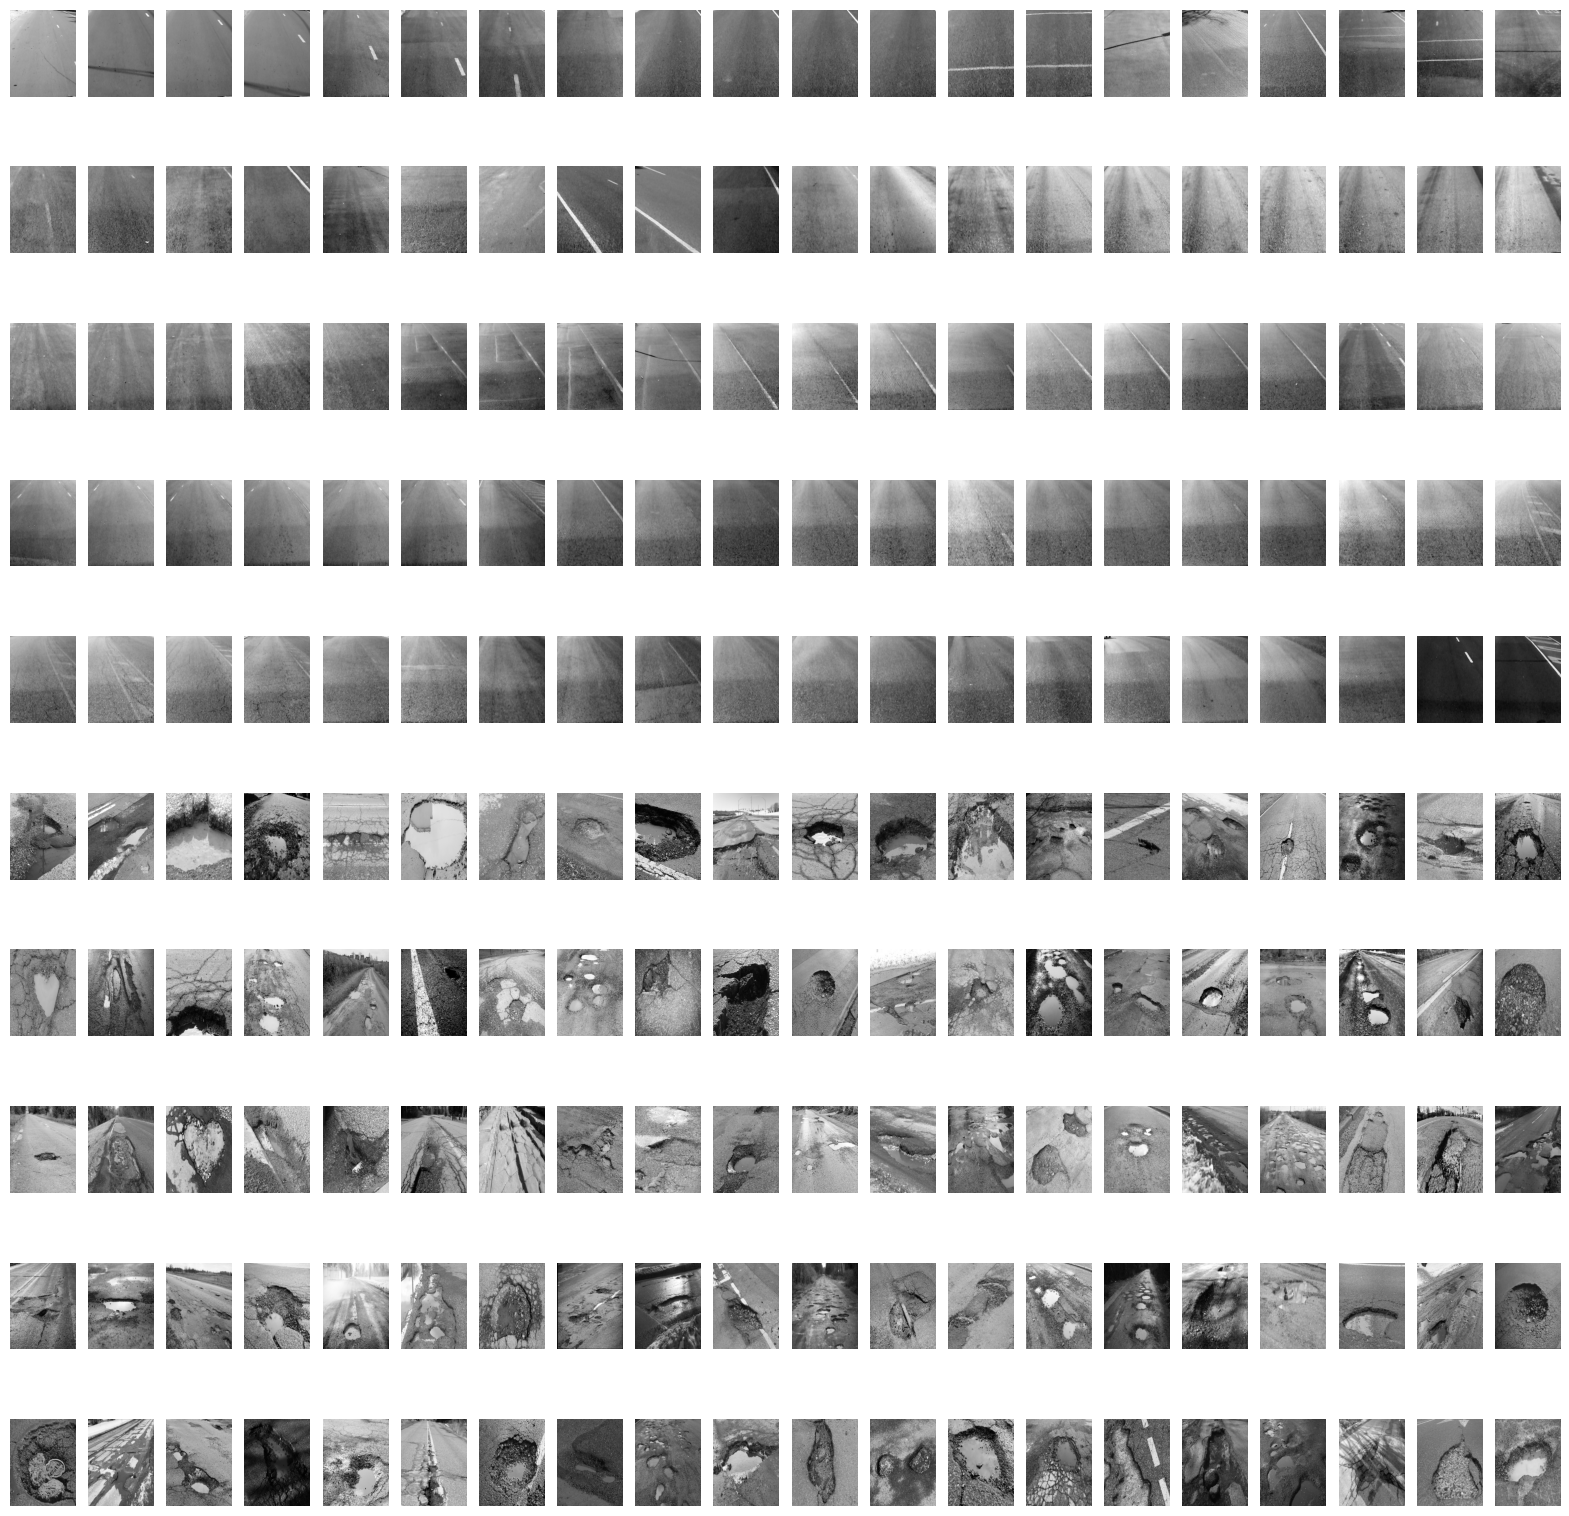

In [14]:
def displayImg(row, column, data):
    fig = plt.figure(figsize=(20, 20))
    for i in range(1, row*column +1):
        fig.add_subplot(row, column, i)
        plt.imshow(data[i-1], cmap='gray')
        plt.axis("off")
    plt.show()

displayImg(10, 20, data)

Cell code di atas merupakan fungsi yang dibuat untuk menampilkan kumpulan citra dalam bentuk grid menggunakan library matplotlib, di mana parameter row dan column menentukan jumlah baris dan kolom grid yang akan dibentuk, sedangkan parameter data merupakan kumpulan citra yang ingin ditampilkan. Di dalam fungsi ini, dilakukan perulangan sebanyak row dikali column, dengan setiap iterasinya menambahkan satu subplot baru ke dalam figure menggunakan fig.add_subplot, kemudian menampilkan citra yang bersangkutan dengan plt.imshow menggunakan colormap "gray" karena citra yang ditampilkan merupakan citra grayscale, serta menyembunyikan sumbu (axis) agar tampilan citra terlihat lebih bersih tanpa garis dan angka koordinat. Pada baris terakhir, fungsi displayImg dipanggil dengan parameter 10 baris dan 20 kolom untuk menampilkan keseluruhan 200 citra yang ada pada variabel "data" sekaligus dalam satu tampilan, sehingga memudahkan dalam melakukan pengecekan visual terhadap seluruh data citra yang telah dimuat sebelumnya.